# Temporal-Correlation Stress Test: Denoising Attacker

The DP mechanisms add **independent** noise to each sample of a z-normalized
window. An ECG window is smooth and strongly **autocorrelated**, so a
temporally-aware adversary can low-pass / denoise the released window to average
much of that noise away while leaving the signal — the signal is correlated
across time, the i.i.d. noise is not.

This notebook reads the output of `scripts/train_reid_denoise.py` and quantifies
that leakage. The privacy mechanism is **unchanged**: the released (noised) data
is held fixed and the attacker simply gains a denoising front end (same data,
smarter adversary). The denoiser is applied identically to the attacker's train
and test inputs, so the comparison is between two adaptive attackers:

| threat model | trains on | evaluates on |
|---|---|---|
| `adaptive_attacker` | DP windows | DP windows |
| `adaptive_denoise_*` | **denoise**(DP windows) | **denoise**(DP windows) |

The **gap** is the re-identification leakage recovered by exploiting temporal
correlation. Both outcomes are publishable: a positive gap means the i.i.d.
mechanism under-protects the autocorrelated signal; a flat gap closes the
reviewer's concern with evidence.

Layout read (same as Notebook 04, new threat-model folders):
`results/reid[/_ecgid]/dp/<mech>/eps_<e>_delta_<d>/<threat_model>/seed_<S>/metrics.pkl`


In [1]:
import os
import pickle
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))

from _loader import load_reid_sweep, load_reid_baseline, load_utility_sweep

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300,
    'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'savefig.bbox': 'tight',
})

# RESULTS / FIGURES are env-overridable so this notebook can be pointed at an
# alternate results root (e.g. for previews) without editing the cell.
RESULTS = Path(os.environ.get('DENOISE_NB_RESULTS', '../results'))
FIGURES = Path(os.environ.get('DENOISE_NB_FIGURES', RESULTS / 'figures'))
FIGURES.mkdir(parents=True, exist_ok=True)

MECH_LABELS = {
    'laplace': 'Laplace',
    'laplace_bounded': 'Bounded Laplace',
    'gaussian_analytic': 'Analytic Gaussian',
}
MECH_MARKERS = {'laplace': 'o', 'laplace_bounded': 's', 'gaussian_analytic': '^'}
MECH_COLORS = {'laplace': '#1f77b4', 'laplace_bounded': '#ff7f0e',
               'gaussian_analytic': '#2ca02c'}

# Which denoising attacker to feature. 'savgol' (Savitzky-Golay) is the
# strongest of the cheap low-pass filters; 'autoencoder' is the learned one.
DENOISE_METHOD = os.environ.get('DENOISE_NB_METHOD', 'savgol')
DENOISE_TM = ('adaptive_denoise_ae' if DENOISE_METHOD == 'autoencoder'
              else f'adaptive_denoise_{DENOISE_METHOD}')
BASE_TM = 'adaptive_attacker'
print(f'Featuring denoising attacker: {DENOISE_TM}  (vs {BASE_TM})')


Featuring denoising attacker: adaptive_denoise_savgol  (vs adaptive_attacker)


## Load results

`load_reid_sweep` already discovers every threat-model folder, so the new
`adaptive_denoise_*` results appear automatically alongside `adaptive_attacker`.
If you ran with `--compare-adaptive`, each denoise record also stores a
**matched** no-denoise number computed on the identical perturbed inputs; we use
that as a fallback when a standalone `adaptive_attacker` sweep is absent.

In [2]:
def load_denoise_detail(results_dir: Path, denoise_tm: str) -> pd.DataFrame:
    '''Read denoise metrics.pkl directly to also pull matched_adaptive / gain.'''
    root = Path(results_dir) / 'dp'
    eps_re = re.compile(r'eps_([0-9.eE+-]+)_delta_([0-9.eE+-]+)')
    rows = []
    if not root.exists():
        return pd.DataFrame()
    for mech_dir in sorted(root.iterdir()):
        if not mech_dir.is_dir():
            continue
        for run_dir in sorted(mech_dir.iterdir()):
            m = eps_re.match(run_dir.name)
            if not m:
                continue
            tm_dir = run_dir / denoise_tm
            if not tm_dir.is_dir():
                continue
            for seed_dir in sorted(tm_dir.glob('seed_*')):
                mp = seed_dir / 'metrics.pkl'
                if not mp.exists():
                    continue
                try:
                    r = pickle.load(open(mp, 'rb'))
                except Exception:
                    continue
                rows.append({
                    'mechanism': mech_dir.name,
                    'eps': float(m.group(1)), 'delta': float(m.group(2)),
                    'seed': int(seed_dir.name.split('_')[1]),
                    'denoise_accuracy': r.get('overall_accuracy'),
                    'matched_adaptive': r.get('matched_adaptive_accuracy'),
                    'attack': r.get('attack'),
                    'method': (r.get('denoise') or {}).get('method'),
                })
    return pd.DataFrame(rows)


def random_floor(reid_dir: Path) -> float:
    base = load_reid_baseline(reid_dir)
    return float(base['random_baseline'].iloc[0]) if not base.empty else np.nan


DBS = {
    'MIT-BIH (intra-record, 22 patients)': RESULTS / 'reid',
    'ECG-ID (cross-session, ~89 subjects)': RESULTS / 'reid_ecgid',
}

sweeps, details, floors = {}, {}, {}
for label, d in DBS.items():
    sweeps[label] = load_reid_sweep(d)
    details[label] = load_denoise_detail(d, DENOISE_TM)
    floors[label] = random_floor(d)
    tms = sorted(sweeps[label]['threat_model'].unique()) if not sweeps[label].empty else []
    print(f'{label}:')
    print(f'   rows={len(sweeps[label])}  threat_models={tms}  random_floor={floors[label]:.3f}')

util_sweep = load_utility_sweep(RESULTS)
print(f'\nUtility sweep rows: {len(util_sweep)}')
if all(s.empty for s in sweeps.values()):
    print('\nNo Re-ID results found. Run:  bash run_denoise_attacker.sh')


MIT-BIH (intra-record, 22 patients):
   rows=525  threat_models=['adaptive_attacker', 'adaptive_denoise_savgol', 'clean_attacker']  random_floor=0.045
ECG-ID (cross-session, ~89 subjects):
   rows=525  threat_models=['adaptive_attacker', 'adaptive_denoise_savgol', 'clean_attacker']  random_floor=0.011

Utility sweep rows: 162


## Build the comparison

For each (mechanism, ε) we aggregate over seeds and line up the adaptive number
against the denoising number. `gain = denoise − adaptive` is the leakage the
temporally-aware attacker recovers.

In [3]:
def build_comparison(sweep: pd.DataFrame, detail: pd.DataFrame) -> pd.DataFrame:
    '''Return per (mech, eps, delta): adapt_mean/std, dn_mean/std, gain.'''
    if sweep.empty:
        return pd.DataFrame()

    def agg(df):
        return (df.groupby(['mechanism', 'eps', 'delta'])['reid_accuracy']
                  .agg(['mean', 'std', 'count']).reset_index())

    dn = sweep[sweep['threat_model'] == DENOISE_TM]
    if dn.empty:
        return pd.DataFrame()
    dn = agg(dn).rename(columns={'mean': 'dn_mean', 'std': 'dn_std', 'count': 'dn_n'})

    ad = sweep[sweep['threat_model'] == BASE_TM]
    if not ad.empty:
        ad = agg(ad).rename(columns={'mean': 'adapt_mean', 'std': 'adapt_std',
                                     'count': 'adapt_n'})
        comp = dn.merge(ad, on=['mechanism', 'eps', 'delta'], how='left')
    else:
        comp = dn.copy()
        comp['adapt_mean'] = np.nan
        comp['adapt_std'] = np.nan

    # Fallback: matched adaptive stored inside the denoise records.
    if comp['adapt_mean'].isna().any() and not detail.empty:
        matched = (detail.dropna(subset=['matched_adaptive'])
                   .groupby(['mechanism', 'eps', 'delta'])['matched_adaptive']
                   .mean().reset_index().rename(columns={'matched_adaptive': 'matched_mean'}))
        comp = comp.merge(matched, on=['mechanism', 'eps', 'delta'], how='left')
        comp['adapt_mean'] = comp['adapt_mean'].fillna(comp['matched_mean'])
        comp = comp.drop(columns=['matched_mean'])

    comp['gain'] = comp['dn_mean'] - comp['adapt_mean']
    comp['gain_std'] = np.sqrt(comp['dn_std'].fillna(0) ** 2
                               + comp['adapt_std'].fillna(0) ** 2)
    return comp.sort_values(['mechanism', 'eps']).reset_index(drop=True)


comps = {label: build_comparison(sweeps[label], details[label]) for label in DBS}
for label, c in comps.items():
    n = 0 if c.empty else len(c)
    print(f'{label}: {n} (mech, eps) comparison points')
comps[list(DBS)[0]].head(12) if not comps[list(DBS)[0]].empty else 'No comparison data yet.'


MIT-BIH (intra-record, 22 patients): 46 (mech, eps) comparison points
ECG-ID (cross-session, ~89 subjects): 46 (mech, eps) comparison points


,mechanism,eps,delta,dn_mean,dn_std,dn_n,adapt_mean,adapt_std,adapt_n,gain,gain_std
0,gaussian_analytic,0.050,0.00001,0.050309,0.002021,3,0.046661,0.000560,3,0.003648,0.002097
1,gaussian_analytic,0.100,0.00001,0.064113,0.005061,3,0.056958,0.002872,3,0.007155,0.005819
2,gaussian_analytic,0.150,0.00001,0.115264,0.007854,3,0.095932,0.005241,3,0.019332,0.009442
3,gaussian_analytic,0.175,0.00001,0.160045,0.002839,3,0.131734,0.004630,3,0.028311,0.005431
4,gaussian_analytic,0.200,0.00001,0.206706,0.003026,3,0.168154,0.010521,3,0.038552,0.010948
5,gaussian_analytic,0.225,0.00001,0.250112,0.004584,3,0.213244,0.002503,3,0.036869,0.005223
6,gaussian_analytic,0.250,0.00001,0.304068,0.006562,3,0.259905,0.014864,3,0.044164,0.016248
7,gaussian_analytic,0.350,0.00001,0.483446,0.007933,3,0.453311,0.008266,3,0.030135,0.011457
8,gaussian_analytic,0.400,0.00001,0.563608,0.004637,3,0.518659,0.014331,3,0.044949,0.015062
9,gaussian_analytic,0.500,0.00001,0.669164,0.005617,3,0.638552,0.013258,3,0.030612,0.014398


## Figure 1 — Overlay: adaptive vs denoising attacker

The headline figure. Solid = adaptive attacker, dashed = same attacker with a
denoising front end. The shaded band is the leakage recovered by exploiting
temporal correlation; the dotted line is the random-guess floor.

Saved: ../results/figures/denoise_attacker_overlay.png


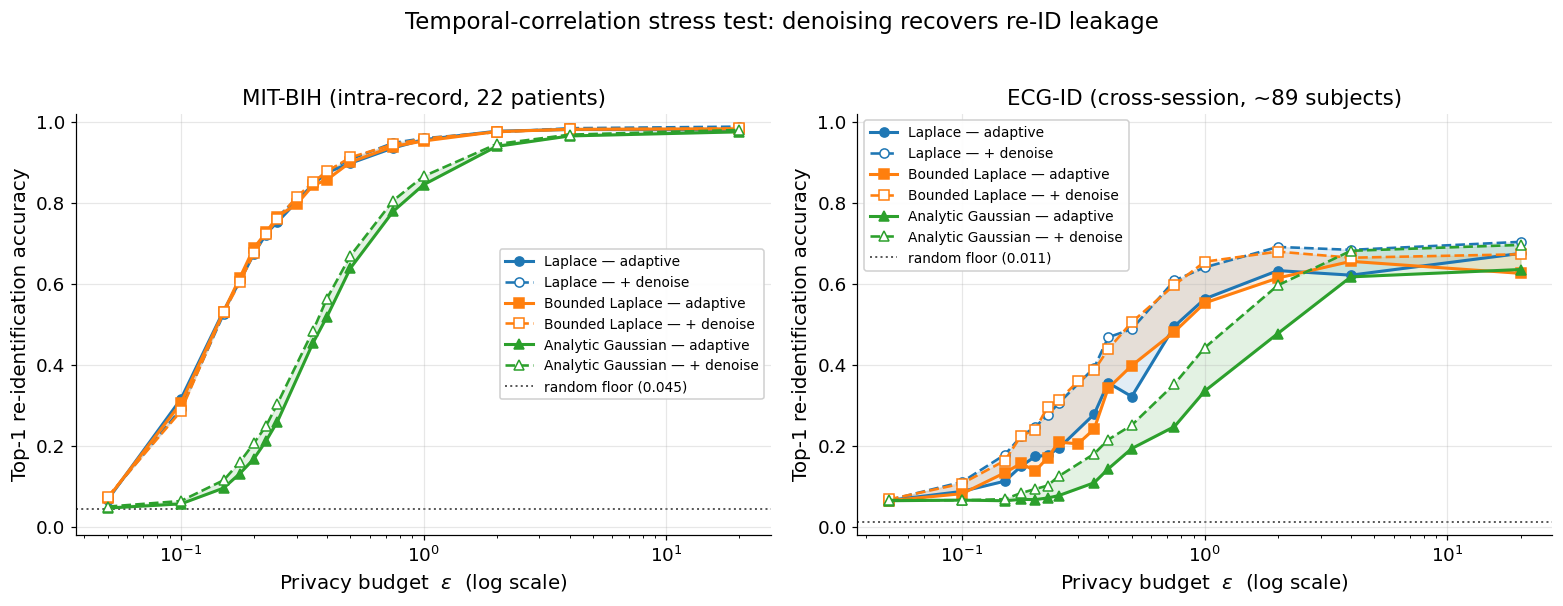

In [4]:
def plot_overlay(comps, floors, save=None):
    have = [l for l in comps if not comps[l].empty]
    if not have:
        print('No data to plot yet — run the sweep first.')
        return
    n = len(have)
    fig, axes = plt.subplots(1, n, figsize=(7.2 * n, 5.4), squeeze=False)
    axes = axes[0]
    for ax, label in zip(axes, have):
        c = comps[label]
        for mech in MECH_LABELS:
            sub = c[c['mechanism'] == mech].sort_values('eps')
            if sub.empty:
                continue
            col = MECH_COLORS[mech]
            x = sub['eps'].values
            ax.fill_between(x, sub['adapt_mean'], sub['dn_mean'],
                            color=col, alpha=0.13, zorder=1)
            ax.plot(x, sub['adapt_mean'], '-', color=col, marker=MECH_MARKERS[mech],
                    lw=2.0, ms=6, zorder=3, label=f'{MECH_LABELS[mech]} — adaptive')
            ax.plot(x, sub['dn_mean'], '--', color=col, marker=MECH_MARKERS[mech],
                    lw=1.7, ms=6, markerfacecolor='white', markeredgecolor=col,
                    zorder=3, label=f'{MECH_LABELS[mech]} — + denoise')
        fl = floors.get(label, np.nan)
        if not np.isnan(fl):
            ax.axhline(fl, color='0.35', ls=':', lw=1.3, zorder=0,
                       label=f'random floor ({fl:.3f})')
        ax.set_xscale('log')
        ax.set_xlabel(r'Privacy budget  $\varepsilon$  (log scale)')
        ax.set_ylabel('Top-1 re-identification accuracy')
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(label)
        ax.legend(fontsize=9, loc='best', framealpha=0.92)
    fig.suptitle('Temporal-correlation stress test: denoising recovers re-ID leakage',
                 fontsize=15, y=1.02)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300)
        print(f'Saved: {save}')
    plt.show()

plot_overlay(comps, floors, save=FIGURES / 'denoise_attacker_overlay.png')


## Figure 2 — Denoising gain $\Delta$ per (mechanism, $\varepsilon$)

The same numbers as bars: $\Delta = $ denoise $-$ adaptive. Bars above zero are
leakage the temporally-aware attacker recovers; error bars combine the seed
spread of both attackers.

Saved: ../results/figures/denoise_attacker_gain.png


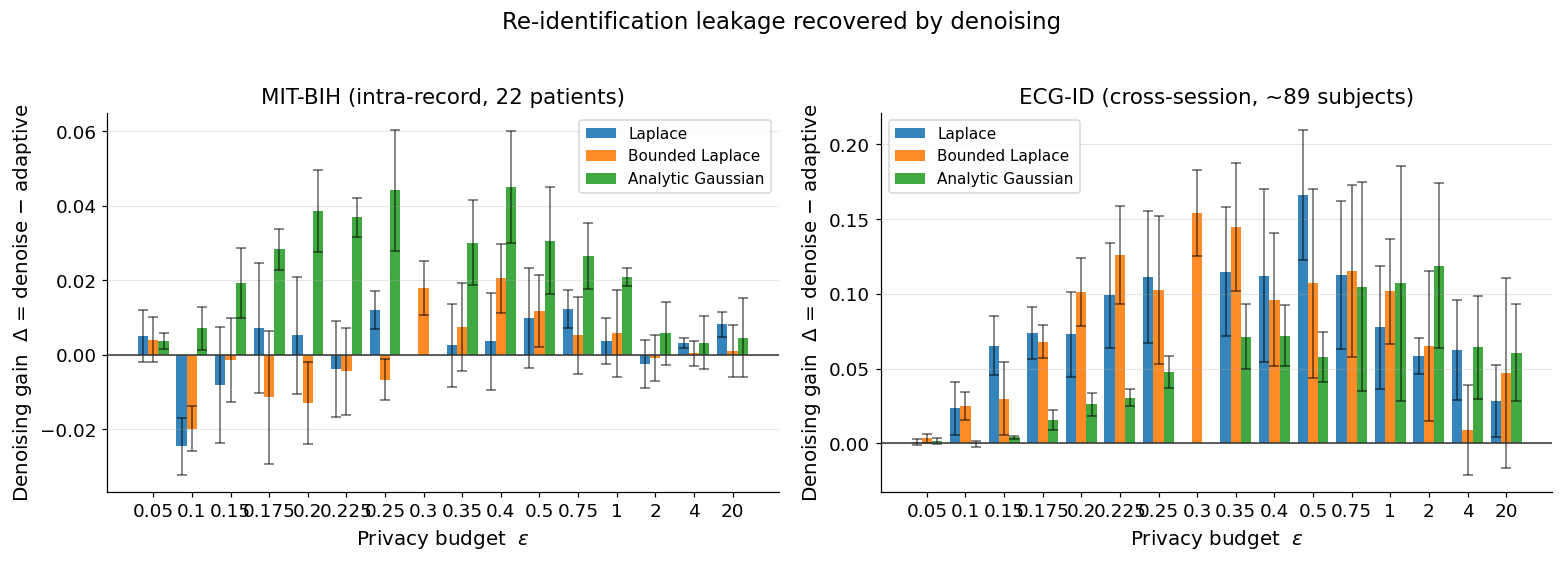

In [5]:
def plot_gain(comps, save=None):
    have = [l for l in comps if not comps[l].empty]
    if not have:
        print('No data to plot yet — run the sweep first.')
        return
    n = len(have)
    fig, axes = plt.subplots(1, n, figsize=(7.2 * n, 5.0), squeeze=False)
    axes = axes[0]
    for ax, label in zip(axes, have):
        c = comps[label]
        eps_vals = sorted(c['eps'].unique())
        x = np.arange(len(eps_vals))
        mechs = [m for m in MECH_LABELS if m in c['mechanism'].unique()]
        w = 0.8 / max(len(mechs), 1)
        for i, mech in enumerate(mechs):
            sub = c[c['mechanism'] == mech].set_index('eps').reindex(eps_vals)
            offs = (i - (len(mechs) - 1) / 2) * w
            ax.bar(x + offs, sub['gain'].values, width=w, color=MECH_COLORS[mech],
                   yerr=sub['gain_std'].values, capsize=3, alpha=0.9,
                   error_kw=dict(lw=1, alpha=0.6), label=MECH_LABELS[mech])
        ax.axhline(0, color='0.2', lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{e:g}' for e in eps_vals])
        ax.set_xlabel(r'Privacy budget  $\varepsilon$')
        ax.set_ylabel(r'Denoising gain  $\Delta$ = denoise $-$ adaptive')
        ax.set_title(label)
        ax.legend(fontsize=10)
        ax.grid(axis='x', alpha=0)
    fig.suptitle('Re-identification leakage recovered by denoising',
                 fontsize=15, y=1.02)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300)
        print(f'Saved: {save}')
    plt.show()

plot_gain(comps, save=FIGURES / 'denoise_attacker_gain.png')


## Figure 3 — Privacy–utility plane with attacker-strength arrows

Each arrow starts at the adaptive attacker and points to the denoising attacker,
at fixed utility (macro-F1). Arrow length = how much re-ID leakage the denoiser
adds; colour encodes $\varepsilon$. Up-and-left is safe-and-useful; the arrows
show the achievable band shifting **right** (worse) under a temporally-aware
adversary.

Saved: ../results/figures/denoise_attacker_moneyfigure.png


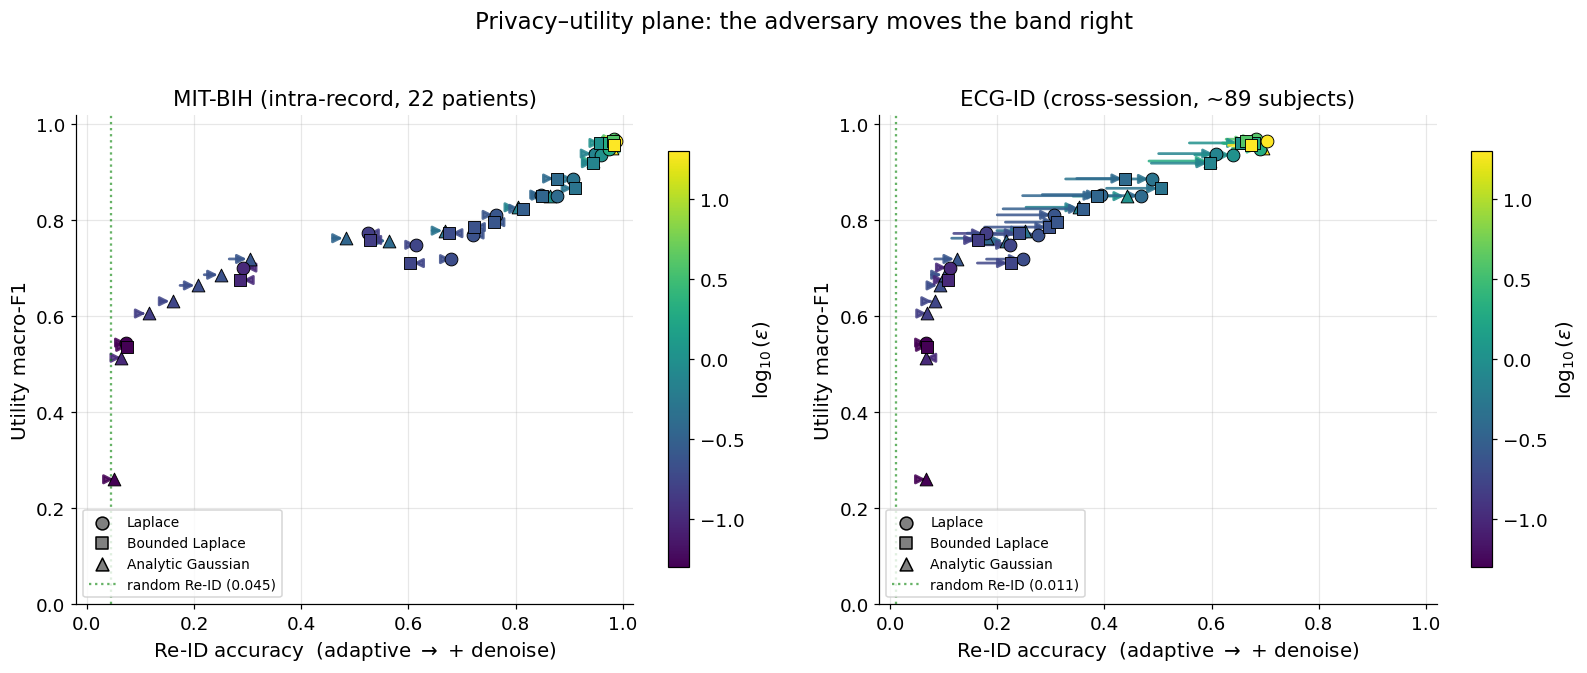

In [6]:
def plot_money(comps, util_sweep, floors, save=None):
    have = [l for l in comps if not comps[l].empty]
    if not have or util_sweep.empty:
        print('Need both Re-ID and utility results — run the sweeps first.')
        return
    util_agg = (util_sweep.groupby(['mechanism', 'eps', 'delta'])['macro_f1']
                .mean().reset_index().rename(columns={'macro_f1': 'util'}))
    n = len(have)
    fig, axes = plt.subplots(1, n, figsize=(7.4 * n, 6.0), squeeze=False)
    axes = axes[0]
    all_eps = sorted(set(np.concatenate([comps[l]['eps'].unique() for l in have])))
    norm = plt.Normalize(np.log10(min(all_eps)), np.log10(max(all_eps)))
    cmap = plt.cm.viridis
    for ax, label in zip(axes, have):
        c = comps[label].merge(util_agg, on=['mechanism', 'eps', 'delta'], how='left')
        c = c.dropna(subset=['util'])
        for _, r in c.iterrows():
            col = cmap(norm(np.log10(r['eps'])))
            ax.add_patch(FancyArrowPatch(
                (r['adapt_mean'], r['util']), (r['dn_mean'], r['util']),
                arrowstyle='-|>', mutation_scale=12, lw=1.8, color=col,
                alpha=0.85, zorder=2))
            ax.scatter(r['dn_mean'], r['util'], marker=MECH_MARKERS[r['mechanism']],
                       color=col, s=70, edgecolor='black', lw=0.6, zorder=3)
        for mech in [m for m in MECH_LABELS if m in c['mechanism'].unique()]:
            ax.scatter([], [], marker=MECH_MARKERS[mech], s=70, facecolor='gray',
                       edgecolor='black', label=MECH_LABELS[mech])
        fl = floors.get(label, np.nan)
        if not np.isnan(fl):
            ax.axvline(fl, color='green', ls=':', alpha=0.6,
                       label=f'random Re-ID ({fl:.3f})')
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(0, 1.02)
        ax.set_xlabel(r'Re-ID accuracy  (adaptive $\rightarrow$ + denoise)')
        ax.set_ylabel('Utility macro-F1')
        ax.set_title(label)
        ax.legend(fontsize=9, loc='lower left')
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
        fig.colorbar(sm, ax=ax, label=r'$\log_{10}(\varepsilon)$', shrink=0.85)
    fig.suptitle('Privacy–utility plane: the adversary moves the band right',
                 fontsize=15, y=1.02)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300)
        print(f'Saved: {save}')
    plt.show()

plot_money(comps, util_sweep, floors, save=FIGURES / 'denoise_attacker_moneyfigure.png')


## Quantitative summary table + CSV export

The compact table the paper needs: adaptive vs denoise re-ID and the gap, per
(database, mechanism, ε). Exported to `results/denoise_attacker_summary.csv`.

In [7]:
out_rows = []
for label, c in comps.items():
    if c.empty:
        continue
    db = 'mitbih' if label.startswith('MIT') else 'ecgid'
    t = c.copy()
    t.insert(0, 'database', db)
    out_rows.append(t[['database', 'mechanism', 'eps', 'delta',
                       'adapt_mean', 'adapt_std', 'dn_mean', 'dn_std',
                       'gain', 'gain_std']])

if out_rows:
    summary = pd.concat(out_rows, ignore_index=True)
    show = summary.rename(columns={
        'adapt_mean': 'adaptive', 'dn_mean': f'+denoise({DENOISE_METHOD})',
        'gain': 'Δ gain'})
    cols = ['database', 'mechanism', 'eps', 'adaptive',
            f'+denoise({DENOISE_METHOD})', 'Δ gain']
    print(show[cols].round(3).to_string(index=False))
    out_path = RESULTS / 'denoise_attacker_summary.csv'
    summary.round(5).to_csv(out_path, index=False)
    print(f'\nSaved: {out_path}  ({len(summary)} rows)')
else:
    summary = pd.DataFrame()
    print('No comparison data to summarize yet.')


database         mechanism    eps  adaptive  +denoise(savgol)  Δ gain
  mitbih gaussian_analytic  0.050     0.047             0.050   0.004
  mitbih gaussian_analytic  0.100     0.057             0.064   0.007
  mitbih gaussian_analytic  0.150     0.096             0.115   0.019
  mitbih gaussian_analytic  0.175     0.132             0.160   0.028
  mitbih gaussian_analytic  0.200     0.168             0.207   0.039
  mitbih gaussian_analytic  0.225     0.213             0.250   0.037
  mitbih gaussian_analytic  0.250     0.260             0.304   0.044
  mitbih gaussian_analytic  0.350     0.453             0.483   0.030
  mitbih gaussian_analytic  0.400     0.519             0.564   0.045
  mitbih gaussian_analytic  0.500     0.639             0.669   0.031
  mitbih gaussian_analytic  0.750     0.779             0.805   0.027
  mitbih gaussian_analytic  1.000     0.844             0.865   0.021
  mitbih gaussian_analytic  2.000     0.939             0.945   0.006
  mitbih gaussian_an

## Paper-ready takeaway

Auto-generates the one or two sentences on direction and magnitude for the
attacker / limitations section.

In [8]:
def takeaway(summary):
    if summary.empty:
        return 'No results yet. Run bash run_denoise_attacker.sh, then re-run this notebook.'
    lines = []
    for db in summary['database'].unique():
        s = summary[summary['database'] == db]
        mean_gain = s['gain'].mean()
        w = s.loc[s['gain'].idxmax()]
        direction = ('raises' if mean_gain > 0.01 else
                     'does not meaningfully change')
        lines.append(
            f'On {db}, a {DENOISE_METHOD} denoising front end {direction} '
            f'adaptive re-identification (mean Δ = {mean_gain:+.3f} across the '
            f'swept ε; largest at {w["mechanism"]}, ε={w["eps"]:g}: '
            f'{w["adapt_mean"]:.3f} → {w["dn_mean"]:.3f}, Δ={w["gain"]:+.3f}).')
    verdict = ('This is direct evidence that the i.i.d. mechanism under-protects '
               'the autocorrelated signal.' if summary['gain'].mean() > 0.01 else
               'This closes the reviewer concern: the i.i.d. mechanism is robust '
               'to temporal post-processing here.')
    return '\n\n'.join(lines) + '\n\n' + verdict

print(takeaway(summary))


On mitbih, a savgol denoising front end does not meaningfully change adaptive re-identification (mean Δ = +0.009 across the swept ε; largest at gaussian_analytic, ε=0.4: 0.519 → 0.564, Δ=+0.045).

On ecgid, a savgol denoising front end raises adaptive re-identification (mean Δ = +0.071 across the swept ε; largest at laplace, ε=0.5: 0.322 → 0.488, Δ=+0.166).

This is direct evidence that the i.i.d. mechanism under-protects the autocorrelated signal.
